# Bird Flight Intelligence: AI Classifier and Wing Model Generator

## AI Class Project Notebook

This notebook builds an AI program that analyzes bird morphology data, groups birds by likely flight characteristics, trains a classifier to predict those groups, explains the prediction, and generates a simplified wing model image.

The project combines:

- data preprocessing
- feature engineering
- unsupervised learning with K-means clustering
- supervised learning with a Random Forest classifier
- model evaluation
- explainable AI-style reasoning
- procedural image generation based on AI output

## Main idea

Birds have different wing shapes and body proportions depending on how they fly.  
This program uses morphology features such as body mass, wing length, wingspan, and hand-wing index to infer flight-style groups.


## 1. Imports

Run this cell first. The notebook uses standard Python data science libraries.


In [80]:
import os
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load the bird dataset

Place your bird dataset CSV file in the same folder as this notebook.

Recommended filename:

```text
AVONET_BirdLife.csv
```

If your file has a different name, change the value of `DATA_PATH` below.


In [81]:
DATA_PATH = "AVONET_BirdLife.csv"

if not os.path.exists(DATA_PATH):
    print(f"Could not find {DATA_PATH}.")
    print("Put your bird morphology CSV in the same folder as this notebook,")
    print("or change DATA_PATH to the correct filename.")
else:
    birds_raw = pd.read_csv(DATA_PATH)
    print("Dataset loaded successfully!")
    print("Shape:", birds_raw.shape)
    display(birds_raw.head())


Dataset loaded successfully!
Shape: (11009, 37)


,Sequence,Species1,Family1,Order1,Avibase.ID1,Total.individuals,Female,Male,Unknown,Complete.measures,...,Habitat.Density,Migration,Trophic.Level,Trophic.Niche,Primary.Lifestyle,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size
0,3103.0,Accipiter albogularis,Accipitridae,Accipitriformes,AVIBASE-BBB59880,5,2,0,3,4,...,1,2.0,Carnivore,Vertivore,Insessorial,-11.73,-4.02,-8.15,158.49,37461.21
1,3090.0,Accipiter badius,Accipitridae,Accipitriformes,AVIBASE-1A0ECB6E,10,4,6,0,8,...,2,3.0,Carnivore,Vertivore,Insessorial,-29.47,46.39,8.23,44.98,22374973.00
2,3125.0,Accipiter bicolor,Accipitridae,Accipitriformes,AVIBASE-ADBE44E1,11,4,5,2,8,...,2,2.0,Carnivore,Vertivore,Generalist,-55.72,23.73,-10.10,-59.96,14309701.27
3,3116.0,Accipiter brachyurus,Accipitridae,Accipitriformes,AVIBASE-68BF920B,4,4,0,0,3,...,1,2.0,Carnivore,Vertivore,Insessorial,-6.31,-4.08,-5.45,150.68,35580.71
4,3092.0,Accipiter brevipes,Accipitridae,Accipitriformes,AVIBASE-8492E4B7,8,4,4,0,4,...,1,3.0,Carnivore,Vertivore,Generalist,31.19,55.86,45.24,45.33,2936751.80


## 3. Inspect column names

This step helps us understand what columns are available in the dataset.

The notebook includes a helper function that tries to automatically detect columns such as species, mass, wing length, wingspan, and hand-wing index.


In [82]:
if "birds_raw" in globals():
    print("Available columns:")
    for col in birds_raw.columns:
        print("-", col)


Available columns:
- Sequence
- Species1
- Family1
- Order1
- Avibase.ID1
- Total.individuals
- Female
- Male
- Unknown
- Complete.measures
- Beak.Length_Culmen
- Beak.Length_Nares
- Beak.Width
- Beak.Depth
- Tarsus.Length
- Wing.Length
- Kipps.Distance
- Secondary1
- Hand-Wing.Index
- Tail.Length
- Mass
- Mass.Source
- Mass.Refs.Other
- Inference
- Traits.inferred
- Reference.species
- Habitat
- Habitat.Density
- Migration
- Trophic.Level
- Trophic.Niche
- Primary.Lifestyle
- Min.Latitude
- Max.Latitude
- Centroid.Latitude
- Centroid.Longitude
- Range.Size


## 4. Automatically detect important columns

Because datasets often use slightly different column names, this function searches for likely matches.

You can manually override the selected columns if the automatic choices are wrong.


In [83]:
def find_column(df, possible_keywords):
    """Find the first column whose name contains one of the keyword patterns."""
    columns = list(df.columns)
    lower_cols = {col: col.lower().replace("_", " ").replace("-", " ") for col in columns}

    for keywords in possible_keywords:
        for col, normalized in lower_cols.items():
            if all(keyword.lower() in normalized for keyword in keywords):
                return col
    return None


if "birds_raw" in globals():
    species_col = find_column(birds_raw, [
        ["species"],
        ["scientific", "name"],
        ["common", "name"]
    ])

    mass_col = find_column(birds_raw, [
        ["mass"],
        ["body", "mass"],
        ["weight"]
    ])

    wing_col = find_column(birds_raw, [
        ["wing", "length"],
        ["wing"]
    ])

    wingspan_col = find_column(birds_raw, [
        ["wingspan"],
        ["wing", "span"],
        ["span"]
    ])

    hwi_col = find_column(birds_raw, [
        ["hwi"],
        ["hand", "wing"],
        ["hand wing index"]
    ])

    tail_col = find_column(birds_raw, [
        ["tail"],
        ["tail", "length"]
    ])

    detected_columns = {
        "species_col": species_col,
        "mass_col": mass_col,
        "wing_col": wing_col,
        "wingspan_col": wingspan_col,
        "hwi_col": hwi_col,
        "tail_col": tail_col,
    }

    detected_columns


### Optional manual column override

If the detected columns are incorrect, uncomment and edit the lines below.

For example:

```python
species_col = "Species1"
mass_col = "Mass"
wing_col = "Wing.Length"
hwi_col = "Hand-Wing.Index"
```


In [84]:
# Optional manual override:
# species_col = "Species1"
# mass_col = "Mass"
# wing_col = "Wing.Length"
# wingspan_col = None
# hwi_col = "Hand-Wing.Index"
# tail_col = "Tail.Length"


## 5. Create a clean working dataset

The model needs numeric morphology features.

At minimum, we need:

- bird name or species
- body mass
- wing length

If wingspan is missing, we estimate it from wing length.  
If hand-wing index is missing, the notebook still works using the other engineered features.


In [85]:
def build_working_dataset(df):
    if species_col is None:
        df = df.copy()
        df["GeneratedSpeciesName"] = ["Bird_" + str(i) for i in range(len(df))]
        local_species_col = "GeneratedSpeciesName"
    else:
        local_species_col = species_col

    required = [local_species_col, mass_col, wing_col]
    missing = [col for col in required if col is None]
    if missing:
        raise ValueError(
            "Could not detect the minimum required columns. "
            "Please manually set species_col, mass_col, and wing_col."
        )

    cols = [local_species_col, mass_col, wing_col]
    if wingspan_col is not None:
        cols.append(wingspan_col)
    if hwi_col is not None:
        cols.append(hwi_col)
    if tail_col is not None:
        cols.append(tail_col)

    work = df[cols].copy()
    rename_map = {
        local_species_col: "species",
        mass_col: "mass_raw",
        wing_col: "wing_length_raw"
    }
    if wingspan_col is not None:
        rename_map[wingspan_col] = "wingspan_raw"
    if hwi_col is not None:
        rename_map[hwi_col] = "hwi"
    if tail_col is not None:
        rename_map[tail_col] = "tail_length_raw"

    work = work.rename(columns=rename_map)

    numeric_cols = [c for c in work.columns if c != "species"]
    for col in numeric_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")

    work = work.dropna(subset=["mass_raw", "wing_length_raw"])
    work = work[work["mass_raw"] > 0]
    work = work[work["wing_length_raw"] > 0]
    work = work.drop_duplicates(subset=["species"])

    return work


if "birds_raw" in globals():
    birds = build_working_dataset(birds_raw)
    print("Clean working dataset shape:", birds.shape)
    display(birds.head())


Clean working dataset shape: (11009, 5)


,species,mass_raw,wing_length_raw,hwi,tail_length_raw
0,Accipiter albogularis,248.8,235.2,33.9,169.0
1,Accipiter badius,131.2,186.7,32.9,140.6
2,Accipiter bicolor,287.5,229.6,24.6,186.3
3,Accipiter brachyurus,142.0,202.2,31.7,140.8
4,Accipiter brevipes,186.5,217.6,40.2,153.5


## 6. Feature engineering

Raw bird measurements are useful, but the AI model becomes more meaningful when we create biological flight features.

This notebook computes:

- `mass_kg`
- `wing_length_m`
- `wingspan_m`
- `aspect_ratio_est`
- `wing_area_m2`
- `wing_loading_N_m2`
- `morphology_based_speed_index`

### Feature logic

- **Aspect ratio**: long narrow wings usually support efficient gliding or soaring.
- **Wing loading**: mass supported per unit wing area; higher values often suggest faster, more power-demanding flight.
- **Speed index**: a simplified estimated score combining wing loading and wing shape.

These are approximate educational features, not professional ornithology measurements.


In [86]:
def infer_length_unit(series):
    """Infer whether values are probably mm, cm, or m based on magnitude."""
    median = series.dropna().median()
    if median > 100:
        return "mm"
    elif median > 2:
        return "cm"
    else:
        return "m"


def convert_length_to_m(series):
    unit = infer_length_unit(series)
    if unit == "mm":
        return series / 1000.0
    elif unit == "cm":
        return series / 100.0
    return series


def infer_mass_unit(series):
    """Infer whether mass values are probably grams or kilograms based on magnitude."""
    median = series.dropna().median()
    if median > 10:
        return "g"
    return "kg"


def convert_mass_to_kg(series):
    unit = infer_mass_unit(series)
    if unit == "g":
        return series / 1000.0
    return series


def robust_01(series):
    """Return a 0-1 normalized version of a numeric series using 5th/95th percentiles."""
    low, high = series.quantile([0.05, 0.95])
    if high == low:
        return pd.Series(0.5, index=series.index)
    return ((series - low) / (high - low)).clip(0, 1)


def engineer_features(df):
    out = df.copy()

    out["mass_kg"] = convert_mass_to_kg(out["mass_raw"])
    out["wing_length_m"] = convert_length_to_m(out["wing_length_raw"])

    # Fill or estimate HWI first, because it is very useful for creating a varied wing shape.
    if "hwi" not in out.columns:
        out["hwi"] = np.nan

    if out["hwi"].notna().any():
        hwi_median = out["hwi"].median()
    else:
        hwi_median = 25

    out["hwi_filled"] = out["hwi"].fillna(hwi_median).clip(0, 100)

    # If wingspan is available, use it.
    # If not, estimate it using wing length plus HWI.
    # The previous notebook used a constant multiplier, which made aspect ratio nearly identical for every bird.
    # This version varies the multiplier: higher HWI -> longer, more pointed effective wing.
    if "wingspan_raw" in out.columns:
        out["wingspan_m"] = convert_length_to_m(out["wingspan_raw"])
    else:
        wingspan_multiplier = 1.75 + 0.012 * out["hwi_filled"]
        out["wingspan_m"] = out["wing_length_m"] * wingspan_multiplier

    # Wing area estimate.
    # Higher HWI birds tend to have a narrower effective planform, so the shape factor is slightly smaller.
    shape_factor = (0.31 - 0.0012 * out["hwi_filled"]).clip(0.18, 0.34)
    out["wing_area_m2"] = out["wingspan_m"] * out["wing_length_m"] * shape_factor

    # Aspect ratio = wingspan^2 / wing area.
    out["aspect_ratio_est"] = (out["wingspan_m"] ** 2) / out["wing_area_m2"]

    # If there is no true HWI variation, create a backup effective aspect-ratio adjustment
    # from relative wing length compared with body mass. This prevents identical visualizations.
    if out["aspect_ratio_est"].nunique() <= 3:
        rel_wing = robust_01(np.log(out["wing_length_m"]) - 0.33 * np.log(out["mass_kg"]))
        out["aspect_ratio_est"] = 5.5 + 8.5 * rel_wing

        # Recompute wing area so wing loading is consistent with the new effective aspect ratio.
        out["wing_area_m2"] = (out["wingspan_m"] ** 2) / out["aspect_ratio_est"]

    # Wing loading = weight / wing area.
    g = 9.81
    out["wing_loading_N_m2"] = (out["mass_kg"] * g) / out["wing_area_m2"]

    # Simplified morphology-based speed index.
    # Higher wing loading and higher HWI can correspond to faster/direct flight.
    out["morphology_based_speed_index"] = (
        np.sqrt(out["wing_loading_N_m2"]) * (1 + out["hwi_filled"] / 100)
    )

    if "tail_length_raw" in out.columns:
        out["tail_length_m"] = convert_length_to_m(out["tail_length_raw"])
    else:
        out["tail_length_m"] = np.nan

    final = out.replace([np.inf, -np.inf], np.nan)
    final = final.dropna(subset=[
        "mass_kg",
        "wing_length_m",
        "wingspan_m",
        "wing_area_m2",
        "aspect_ratio_est",
        "wing_loading_N_m2",
        "morphology_based_speed_index"
    ])

    return final


if "birds" in globals():
    birds_features = engineer_features(birds)
    print("Feature dataset shape:", birds_features.shape)
    display(birds_features.head())

    print("\nVariation check for generated wing features:")
    display(
        birds_features[
            ["species", "hwi", "hwi_filled", "wingspan_m", "aspect_ratio_est",
             "wing_loading_N_m2", "morphology_based_speed_index"]
        ].head(10)
    )


Feature dataset shape: (11009, 14)


,species,mass_raw,wing_length_raw,hwi,tail_length_raw,mass_kg,wing_length_m,hwi_filled,wingspan_m,wing_area_m2,aspect_ratio_est,wing_loading_N_m2,morphology_based_speed_index,tail_length_m
0,Accipiter albogularis,248.8,235.2,33.9,169.0,0.2488,2.352,33.9,5.072794,3.213314,8.008317,0.759567,1.166981,1.690
1,Accipiter badius,131.2,186.7,32.9,140.6,0.1312,1.867,32.9,4.004342,2.022436,7.928434,0.636397,1.060203,1.406
2,Accipiter bicolor,287.5,229.6,24.6,186.3,0.2875,2.296,24.6,4.695779,3.023998,7.291786,0.932664,1.203319,1.863
3,Accipiter brachyurus,142.0,202.2,31.7,140.8,0.1420,2.022,31.7,4.307669,2.368801,7.833505,0.588070,1.009951,1.408
4,Accipiter brevipes,186.5,217.6,40.2,153.5,0.1865,2.176,40.2,4.857702,2.766898,8.528423,0.661233,1.140054,1.535



Variation check for generated wing features:


,species,hwi,hwi_filled,wingspan_m,aspect_ratio_est,wing_loading_N_m2,morphology_based_speed_index
0,Accipiter albogularis,33.9,33.9,5.072794,8.008317,0.759567,1.166981
1,Accipiter badius,32.9,32.9,4.004342,7.928434,0.636397,1.060203
2,Accipiter bicolor,24.6,24.6,4.695779,7.291786,0.932664,1.203319
3,Accipiter brachyurus,31.7,31.7,4.307669,7.833505,0.588070,1.009951
4,Accipiter brevipes,40.2,40.2,4.857702,8.528423,0.661233,1.140054
5,Accipiter butleri,25.8,25.8,3.418936,7.381021,0.755724,1.093610
6,Accipiter castanilius,24.0,24.0,3.332130,7.247511,1.008543,1.245286
7,Accipiter cirrocephalus,37.8,37.8,4.693668,8.326784,0.614390,1.080118
8,Accipiter collaris,30.0,30.0,3.500490,7.700730,0.602951,1.009449
9,Accipiter cooperii,32.3,32.3,5.155891,7.880844,1.249682,1.478971


## 7. Select AI features

These are the features that the AI model will use to group and classify birds.


In [87]:
feature_cols = [
    "mass_kg",
    "wing_length_m",
    "wingspan_m",
    "aspect_ratio_est",
    "wing_loading_N_m2",
    "morphology_based_speed_index"
]

if "birds_features" in globals():
    # Include HWI if enough values exist, or use hwi_filled if it was created during feature engineering.
    if "hwi_filled" in birds_features.columns:
        feature_cols.append("hwi_filled")
    elif birds_features["hwi"].notna().sum() > len(birds_features) * 0.5:
        birds_features["hwi_filled"] = birds_features["hwi"].fillna(birds_features["hwi"].median())
        feature_cols.append("hwi_filled")

    # Remove accidental duplicates.
    feature_cols = list(dict.fromkeys(feature_cols))

    X = birds_features[feature_cols].copy()
    print("Features used by model:")
    print(feature_cols)
    display(X.describe())


Features used by model:
['mass_kg', 'wing_length_m', 'wingspan_m', 'aspect_ratio_est', 'wing_loading_N_m2', 'morphology_based_speed_index', 'hwi_filled']


,mass_kg,wing_length_m,wingspan_m,aspect_ratio_est,wing_loading_N_m2,morphology_based_speed_index,hwi_filled
count,11009.000000,11009.000000,11009.000000,11009.000000,1.100900e+04,11009.000000,11009.000000
mean,0.267147,1.247826,2.627111,7.431432,1.613612e+04,3.864696,25.439213
std,1.883035,0.934361,2.127501,1.216619,7.722264e+05,127.104286,14.853214
min,0.001900,0.001000,0.001751,5.651220,8.642678e-02,0.462317,0.100000
25%,0.015000,0.668000,1.324747,6.623252,5.451769e-01,0.893610,15.200000
50%,0.035500,0.915000,1.831009,7.029494,7.400893e-01,1.038780,21.000000
75%,0.121000,1.455000,3.061076,7.817781,1.059710e+00,1.268410,31.500000
max,111.000000,7.899000,18.079231,11.961601,4.194897e+07,6483.279124,74.300000


## 8. Unsupervised learning: K-means clustering

Since real flight-style labels may not exist in the dataset, we use K-means clustering.

The algorithm groups birds based on similarities in their morphology and engineered flight features.


In [88]:
N_CLUSTERS = 5

if "X" in globals():
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
    birds_features["cluster"] = kmeans.fit_predict(X_scaled)

    print("Cluster counts:")
    display(birds_features["cluster"].value_counts().sort_index())


Cluster counts:


cluster
0     922
1    8215
2       5
3    1865
4       2
Name: count, dtype: int64

## 9. Interpret clusters as flight-style groups

K-means gives numeric cluster labels like 0, 1, 2, 3, and 4.

To make the result understandable, we interpret each cluster based on its average features.


In [89]:
def interpret_cluster(row, global_means):
    ar = row["aspect_ratio_est"]
    wl = row["wing_loading_N_m2"]
    si = row["morphology_based_speed_index"]
    mass = row["mass_kg"]

    high_ar = ar > global_means["aspect_ratio_est"]
    high_wl = wl > global_means["wing_loading_N_m2"]
    high_si = si > global_means["morphology_based_speed_index"]
    high_mass = mass > global_means["mass_kg"]

    if high_ar and not high_wl:
        return "Soaring / gliding flyers"
    elif high_si and high_wl:
        return "Fast direct flyers"
    elif not high_ar and not high_wl:
        return "Agile maneuvering flyers"
    elif high_mass and high_wl:
        return "Heavy high-power flyers"
    else:
        return "Generalist flyers"


if "birds_features" in globals() and "cluster" in birds_features.columns:
    cluster_summary = birds_features.groupby("cluster")[feature_cols].mean()
    global_means = birds_features[feature_cols].mean()

    cluster_to_style = {}
    for cluster_id, row in cluster_summary.iterrows():
        cluster_to_style[cluster_id] = interpret_cluster(row, global_means)

    birds_features["flight_style"] = birds_features["cluster"].map(cluster_to_style)

    print("Cluster interpretation:")
    for cluster_id, style in cluster_to_style.items():
        print(f"Cluster {cluster_id}: {style}")

    display(cluster_summary)


Cluster interpretation:
Cluster 0: Soaring / gliding flyers
Cluster 1: Agile maneuvering flyers
Cluster 2: Fast direct flyers
Cluster 3: Soaring / gliding flyers
Cluster 4: Agile maneuvering flyers


,mass_kg,wing_length_m,wingspan_m,aspect_ratio_est,wing_loading_N_m2,morphology_based_speed_index,hwi_filled
cluster,,,,,,,
0,1.922776,3.702709,8.165790,8.342922,2.814235e+00,1.807257,37.208785
1,0.079108,0.931677,1.847186,6.866444,9.942755e-01,1.083334,18.520329
2,1.965200,0.001000,0.001751,5.651220,3.552601e+07,5931.811712,0.100000
3,0.153632,1.425626,3.324016,9.476179,8.392289e-01,1.235909,50.192279
4,111.000000,5.447500,9.539662,5.651220,6.842612e+01,8.263963,0.100000


## 10. Visualize bird clusters

This plot shows birds based on two important flight-related features:

- wing loading
- morphology-based speed index

The colors represent AI-discovered clusters.


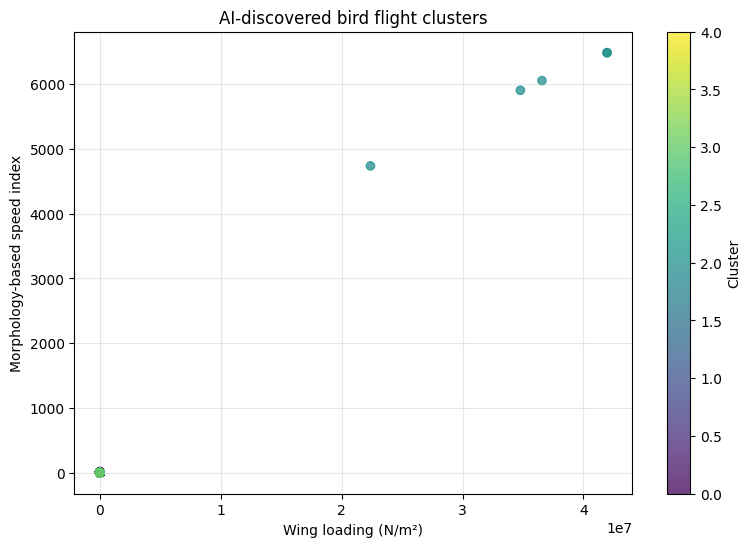

In [90]:
if "birds_features" in globals() and "cluster" in birds_features.columns:
    plt.figure(figsize=(9, 6))
    scatter = plt.scatter(
        birds_features["wing_loading_N_m2"],
        birds_features["morphology_based_speed_index"],
        c=birds_features["cluster"],
        alpha=0.75
    )
    plt.xlabel("Wing loading (N/m²)")
    plt.ylabel("Morphology-based speed index")
    plt.title("AI-discovered bird flight clusters")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True, alpha=0.3)
    plt.show()


## 11. Supervised learning: train a classifier

Now that K-means created flight-style group labels, we train a classifier to predict the group for new birds.

This makes the project a complete AI pipeline:

1. Discover groups using unsupervised learning.
2. Train a supervised model to predict those groups.
3. Explain and visualize predictions.


In [91]:
if "birds_features" in globals() and "cluster" in birds_features.columns:
    y = birds_features["cluster"]

    # Stratify only if every cluster has at least 2 examples.
    counts = y.value_counts()
    stratify_arg = y if counts.min() >= 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=stratify_arg
    )

    classifier = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            max_depth=None
        ))
    ])

    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"Classifier accuracy on test set: {acc:.3f}")
    print()
    print("Classification report:")
    print(classification_report(y_test, y_pred))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))


Classifier accuracy on test set: 0.996

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       231
           1       1.00      1.00      1.00      2054
           2       1.00      1.00      1.00         1
           3       0.99      0.99      0.99       466
           4       1.00      1.00      1.00         1

    accuracy                           1.00      2753
   macro avg       0.99      0.99      0.99      2753
weighted avg       1.00      1.00      1.00      2753

Confusion matrix:
[[ 226    3    0    2    0]
 [   2 2051    0    1    0]
 [   0    0    1    0    0]
 [   2    1    0  463    0]
 [   0    0    0    0    1]]


## 12. Feature importance

Random Forest can estimate which features were most important for predicting the bird flight groups.


,feature,importance
6,hwi_filled,0.309902
3,aspect_ratio_est,0.295578
2,wingspan_m,0.161518
1,wing_length_m,0.153404
0,mass_kg,0.058808
5,morphology_based_speed_index,0.016643
4,wing_loading_N_m2,0.004146


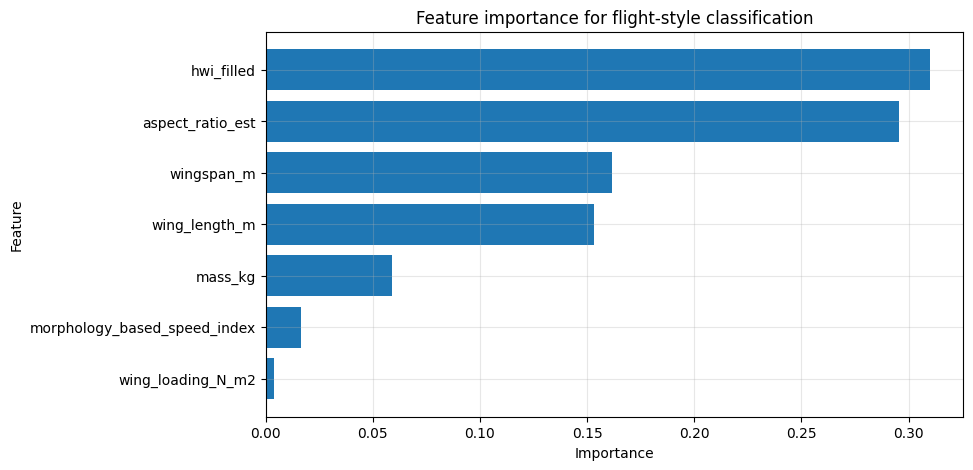

In [92]:
if "classifier" in globals():
    importances = classifier.named_steps["model"].feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": importances
    }).sort_values("importance", ascending=False)

    display(importance_df)

    plt.figure(figsize=(9, 5))
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Feature importance for flight-style classification")
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3)
    plt.show()


## 13. Explain a prediction for one bird

Choose a bird from the dataset and generate an explanation.

You can change `SELECTED_BIRD_INDEX` to test different birds.


In [93]:
SELECTED_BIRD_INDEX = 0

def explain_bird(row, global_medians):
    explanations = []

    if row["aspect_ratio_est"] > global_medians["aspect_ratio_est"]:
        explanations.append("higher-than-average aspect ratio, suggesting longer and narrower wings")
    else:
        explanations.append("lower-than-average aspect ratio, suggesting shorter or broader wings")

    if row["wing_loading_N_m2"] > global_medians["wing_loading_N_m2"]:
        explanations.append("higher-than-average wing loading, which often indicates faster or more power-demanding flight")
    else:
        explanations.append("lower-than-average wing loading, which can support slower flight, maneuvering, or gliding")

    if row["morphology_based_speed_index"] > global_medians["morphology_based_speed_index"]:
        explanations.append("a higher morphology-based speed index")
    else:
        explanations.append("a lower morphology-based speed index")

    if "hwi" in row.index and not pd.isna(row["hwi"]):
        if row["hwi"] > global_medians.get("hwi", row["hwi"]):
            explanations.append("a relatively high hand-wing index, often associated with more efficient long-distance flight")
        else:
            explanations.append("a relatively low hand-wing index, often associated with more maneuverable flight")

    return explanations


if "birds_features" in globals():
    selected = birds_features.iloc[SELECTED_BIRD_INDEX]
    selected_X = selected[feature_cols].to_frame().T
    predicted_cluster = int(classifier.predict(selected_X)[0])
    predicted_style = cluster_to_style[predicted_cluster]

    global_medians = birds_features.median(numeric_only=True)
    reasons = explain_bird(selected, global_medians)

    print("Selected bird:", selected["species"])
    print("Predicted cluster:", predicted_cluster)
    print("Predicted flight style:", predicted_style)
    print()
    print("Explanation:")
    for reason in reasons:
        print("-", reason)


Selected bird: Accipiter albogularis
Predicted cluster: 3
Predicted flight style: Soaring / gliding flyers

Explanation:
- higher-than-average aspect ratio, suggesting longer and narrower wings
- higher-than-average wing loading, which often indicates faster or more power-demanding flight
- a higher morphology-based speed index
- a relatively high hand-wing index, often associated with more efficient long-distance flight


## 14. Generate a simplified wing model image

This part generates a wing image based on the bird's morphology.

The drawing is not a biologically exact wing. It is a simplified visual model created from the AI system's features.

Rules:

- Higher aspect ratio → longer, narrower wing.
- Lower aspect ratio → shorter, broader wing.
- Higher wing loading → thicker visual wing.
- Flight style changes the curve and shape slightly.


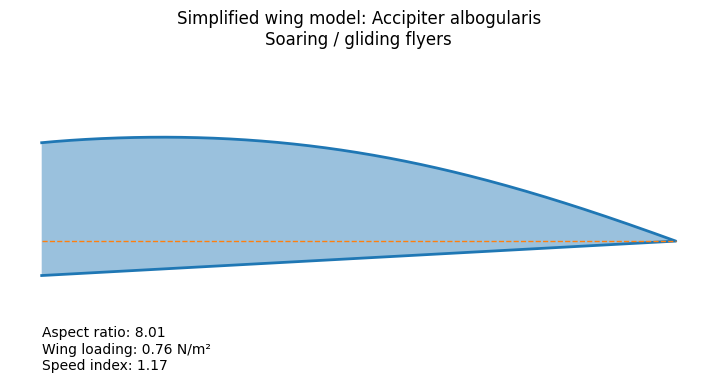

In [94]:
def normalize_value(value, low, high, min_out, max_out):
    if high == low:
        return (min_out + max_out) / 2
    value = max(min(value, high), low)
    return min_out + (value - low) * (max_out - min_out) / (high - low)


def generate_wing_model(row, save_path=None):
    ar_low, ar_high = birds_features["aspect_ratio_est"].quantile([0.05, 0.95])
    wl_low, wl_high = birds_features["wing_loading_N_m2"].quantile([0.05, 0.95])

    aspect_ratio = row["aspect_ratio_est"]
    wing_loading = row["wing_loading_N_m2"]
    style = row["flight_style"]

    length = normalize_value(aspect_ratio, ar_low, ar_high, 3.0, 7.0)
    thickness = normalize_value(wing_loading, wl_low, wl_high, 0.5, 1.6)

    x = np.linspace(0, length, 200)

    if style == "Soaring / gliding flyers":
        top = thickness * (1 - (x / length) ** 1.7) + 0.15 * np.sin(np.pi * x / length)
        bottom = -0.35 * thickness * (1 - x / length)
    elif style == "Fast direct flyers":
        top = thickness * (1 - (x / length)) ** 0.8
        bottom = -0.25 * thickness * (1 - x / length)
    elif style == "Agile maneuvering flyers":
        top = thickness * np.sin(np.pi * x / length) ** 0.6
        bottom = -0.45 * thickness * np.sin(np.pi * x / length) ** 0.8
    elif style == "Heavy high-power flyers":
        top = 1.15 * thickness * (1 - (x / length) ** 1.2)
        bottom = -0.55 * thickness * (1 - x / length)
    else:
        top = thickness * np.sin(np.pi * x / length) ** 0.7
        bottom = -0.30 * thickness * np.sin(np.pi * x / length)

    # Close the polygon.
    wing_x = np.concatenate([x, x[::-1]])
    wing_y = np.concatenate([top, bottom[::-1]])

    plt.figure(figsize=(9, 4))
    plt.fill(wing_x, wing_y, alpha=0.45)
    plt.plot(wing_x, wing_y, linewidth=2)

    # Add a simple leading bone/structure line.
    plt.plot([0, length], [0, 0], linewidth=1, linestyle="--")

    plt.axis("equal")
    plt.axis("off")
    plt.title(f"Simplified wing model: {row['species']}\n{style}")

    info_text = (
        f"Aspect ratio: {aspect_ratio:.2f}\n"
        f"Wing loading: {wing_loading:.2f} N/m²\n"
        f"Speed index: {row['morphology_based_speed_index']:.2f}"
    )
    plt.text(0, -1.3 * thickness, info_text, fontsize=10)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)

    plt.show()


if "birds_features" in globals():
    generate_wing_model(selected)


## 14B. Generate a top-view spread-wing planform

This visualization creates a **top-view wing-shape diagram** instead of drawing a full bird body.

The first version looked too similar across birds because the wing shape depended mostly on the predicted group label.  
If several birds were classified into the same group, their planforms looked almost identical.

This improved version uses **continuous morphology values**:

- `wingspan_m`
- `aspect_ratio_est`
- `wing_loading_N_m2`
- `morphology_based_speed_index`
- `hwi_filled`

That means two birds can belong to the same flight-style group but still produce different wing diagrams.

Rules used:

- larger estimated wingspan → longer displayed wings
- higher aspect ratio → narrower wings
- higher wing loading → thicker wing root
- higher HWI / speed index → sharper, more swept wingtip
- lower HWI → broader tips and more visible feather notches


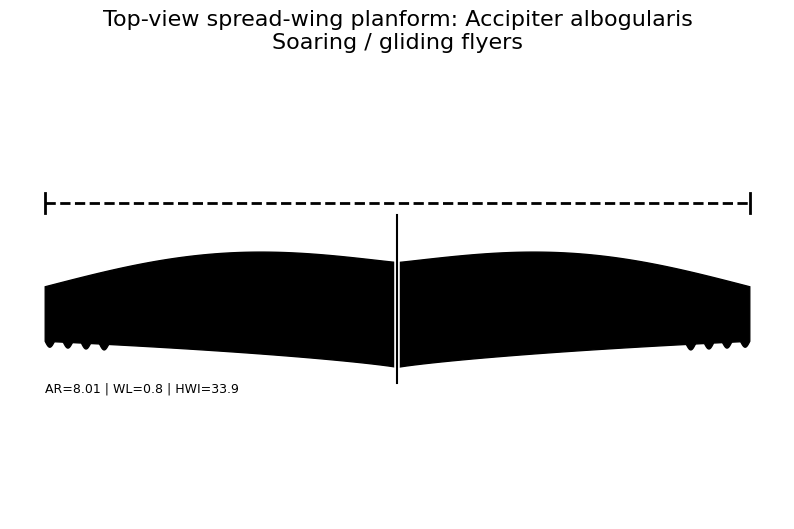

In [95]:
def quantile_norm(value, series, low_q=0.05, high_q=0.95):
    """Normalize one value to 0-1 using dataset quantiles."""
    low, high = series.quantile([low_q, high_q])
    if high == low:
        return 0.5
    return float(np.clip((value - low) / (high - low), 0, 1))


def generate_top_view_wing_planform(row, save_path=None, show_span=True, show_symmetry=True):
    """
    Generate a clean top-view spread-wing visualization using only the wing shape.

    This version uses continuous morphology values, not only the flight-style label.
    That means birds in the same predicted group can still produce visibly different
    wing shapes.
    """

    style = row["flight_style"]

    # Normalize several real/engineered morphology values.
    span_n = quantile_norm(row["wingspan_m"], birds_features["wingspan_m"])
    ar_n = quantile_norm(row["aspect_ratio_est"], birds_features["aspect_ratio_est"])
    load_n = quantile_norm(row["wing_loading_N_m2"], birds_features["wing_loading_N_m2"])
    speed_n = quantile_norm(row["morphology_based_speed_index"], birds_features["morphology_based_speed_index"])

    if "hwi_filled" in row.index and "hwi_filled" in birds_features.columns:
        hwi_n = quantile_norm(row["hwi_filled"], birds_features["hwi_filled"])
    elif "hwi" in row.index and birds_features["hwi"].notna().any():
        hwi_n = quantile_norm(row["hwi"], birds_features["hwi"].dropna())
    else:
        hwi_n = 0.5

    # Main geometry controls.
    # These use exaggerated ranges so the visualization clearly changes between birds.
    half_span = 3.2 + 4.8 * span_n
    root_chord = 2.2 - 0.9 * ar_n + 0.45 * load_n
    tip_chord = 0.95 - 0.55 * hwi_n - 0.25 * speed_n + 0.18 * (1 - ar_n)

    root_chord = float(np.clip(root_chord, 0.85, 2.35))
    tip_chord = float(np.clip(tip_chord, 0.12, 0.95))

    # Continuous shape controls.
    sweep = -0.05 + 0.55 * speed_n + 0.25 * hwi_n
    tip_drop = 0.05 + 0.35 * (1 - ar_n) + 0.20 * load_n
    wing_roundness = 0.06 + 0.28 * (1 - speed_n) + 0.12 * (1 - ar_n)
    feather_amp = 0.03 + 0.12 * (1 - hwi_n) + 0.06 * load_n

    # Style nudges, so class still matters but does not dominate the drawing.
    if style == "Soaring / gliding flyers":
        sweep -= 0.08
        wing_roundness += 0.08
        tip_chord += 0.08
    elif style == "Fast direct flyers":
        sweep += 0.18
        tip_chord -= 0.12
        feather_amp *= 0.7
    elif style == "Agile maneuvering flyers":
        wing_roundness += 0.12
        tip_chord += 0.12
        tip_drop += 0.10
    elif style == "Heavy high-power flyers":
        root_chord += 0.18
        tip_chord += 0.06
        feather_amp *= 0.8

    root_chord = float(np.clip(root_chord, 0.85, 2.45))
    tip_chord = float(np.clip(tip_chord, 0.12, 1.05))

    # Parameter from center to wingtip.
    t = np.linspace(0, 1, 400)

    # Wing x coordinate from center outward.
    x_right = half_span * t

    # Chord tapers from root to tip.
    taper_power = 0.68 + 0.45 * hwi_n
    chord = root_chord * (1 - t**taper_power) + tip_chord * (t**taper_power)

    # Leading edge.
    y_top_right = (
        0.35 * chord
        + wing_roundness * np.sin(np.pi * t)
        - 0.04 * t
        - 0.05 * sweep * t**1.5
    )

    # Trailing edge.
    y_bottom_right = (
        -0.65 * chord
        - tip_drop * (t**1.35)
        + sweep * 0.24 * t
    )

    # Feather notches near wingtip only.
    feather_zone = t > 0.82
    feather_count = int(round(4 + 5 * (1 - hwi_n) + 2 * load_n))
    feather_count = max(3, min(feather_count, 10))
    feather_wave = feather_amp * np.sin(
        feather_count * np.pi * (t[feather_zone] - 0.82) / 0.18
    )
    y_bottom_right[feather_zone] -= np.maximum(feather_wave, 0)

    # Make root clean at center.
    y_top_right[0] = 0.25 * root_chord
    y_bottom_right[0] = -0.62 * root_chord

    # Right wing polygon.
    wing_right_x = np.concatenate([x_right, x_right[::-1]])
    wing_right_y = np.concatenate([y_top_right, y_bottom_right[::-1]])

    # Mirrored left wing.
    wing_left_x = -wing_right_x
    wing_left_y = wing_right_y

    # Plot.
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    ax.set_facecolor("#f2f2f2")

    plt.fill(wing_left_x, wing_left_y, color="black")
    plt.fill(wing_right_x, wing_right_y, color="black")

    # Vertical symmetry line.
    if show_symmetry:
        y_min = min(y_bottom_right.min(), -0.8 * root_chord)
        y_max = max(y_top_right.max(), 0.8 * root_chord)

        # White underlay creates a clean center cut.
        plt.plot([0, 0], [y_min, y_max], color="white", linewidth=4, zorder=5)

        # Thin black line marks the symmetry axis.
        plt.plot([0, 0], [y_min, y_max], color="black", linewidth=1.5, zorder=6)

    # Wingspan indicator.
    if show_span:
        y_line = y_top_right.max() + 0.9
        plt.plot(
            [-half_span, half_span],
            [y_line, y_line],
            linestyle="--",
            linewidth=2,
            color="black"
        )
        plt.plot(
            [-half_span, -half_span],
            [y_line - 0.18, y_line + 0.18],
            color="black",
            linewidth=2
        )
        plt.plot(
            [half_span, half_span],
            [y_line - 0.18, y_line + 0.18],
            color="black",
            linewidth=2
        )

    plt.title(
        f"Top-view spread-wing planform: {row['species']}\n{style}",
        fontsize=16
    )
    plt.axis("equal")
    plt.axis("off")

    # Add a small feature summary so it is obvious why shapes differ.
    info_text = (
        f"AR={row['aspect_ratio_est']:.2f} | "
        f"WL={row['wing_loading_N_m2']:.1f} | "
        f"HWI={row.get('hwi_filled', np.nan):.1f}"
    )
    plt.text(-half_span, y_bottom_right.min() - 0.45, info_text, fontsize=9)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)

    plt.show()


if "birds_features" in globals():
    generate_top_view_wing_planform(selected)


## 14C. Save several top-view wing planform examples

This cell saves multiple generated top-view wing diagrams to a folder called `generated_top_view_wings`.


Birds selected for top-view wing examples:


,species,flight_style,aspect_ratio_est,wing_loading_N_m2,morphology_based_speed_index,hwi_filled
8211,Sporophila hypoxantha,Agile maneuvering flyers,7.314008,6.247195e-01,0.987200,24.9
10853,Apteryx haastii,Fast direct flyers,5.651220,3.656547e+07,6052.986015,0.1
10011,Aechmophorus clarkii,Soaring / gliding flyers,8.665333,4.790795e+00,3.103702,41.8
10852,Apteryx australis,Fast direct flyers,5.651220,4.194897e+07,6483.279124,0.1
10857,Casuarius bennetti,Soaring / gliding flyers,5.651220,1.346137e+02,11.613916,0.1
1098,Vultur gryphus,Soaring / gliding flyers,8.936436,3.013624e+00,2.515434,44.9
597,Zoonavena grandidieri,Soaring / gliding flyers,11.313060,8.642678e-02,0.495952,68.7
570,Cypsiurus parvus,Soaring / gliding flyers,11.961601,1.236475e-01,0.612901,74.3


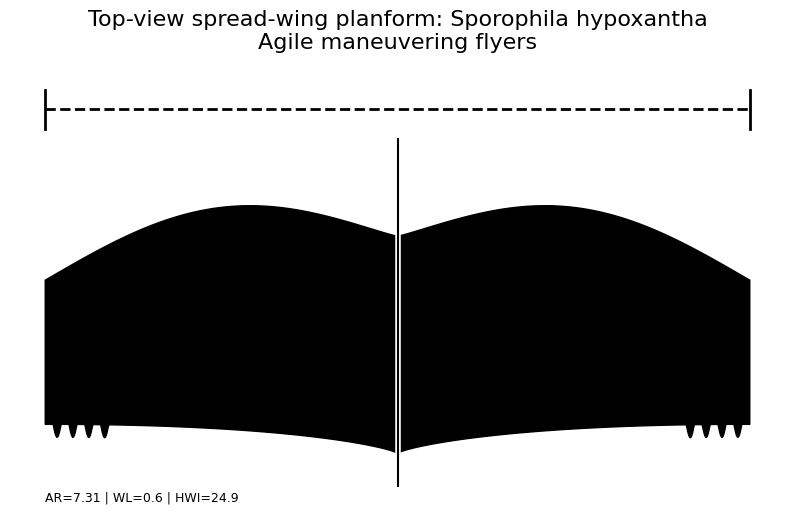

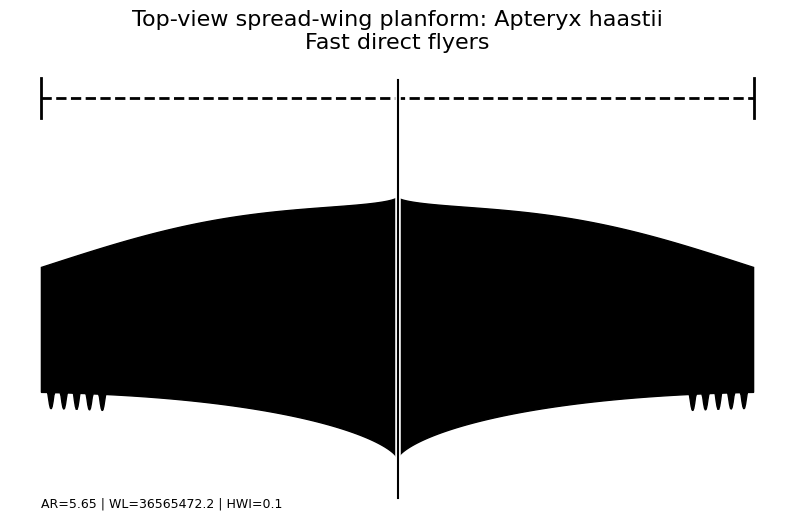

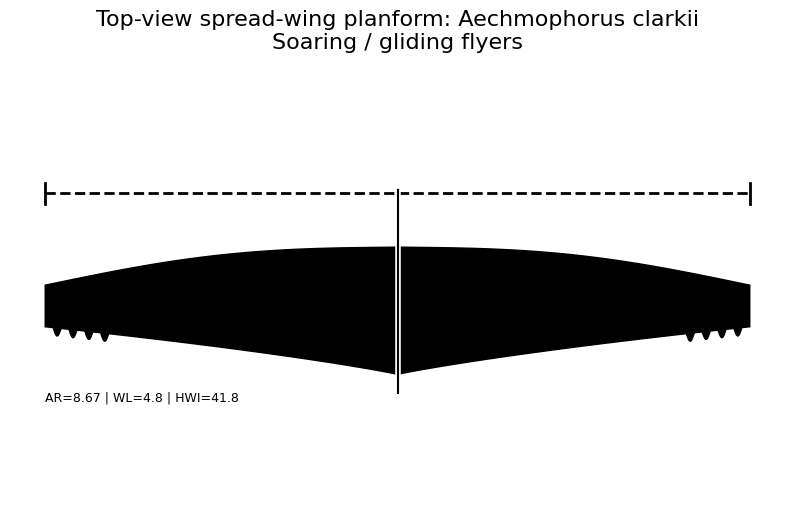

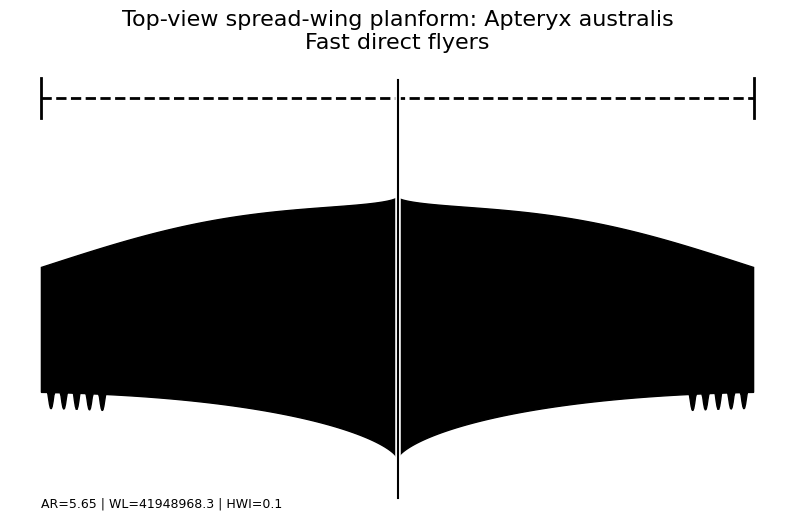

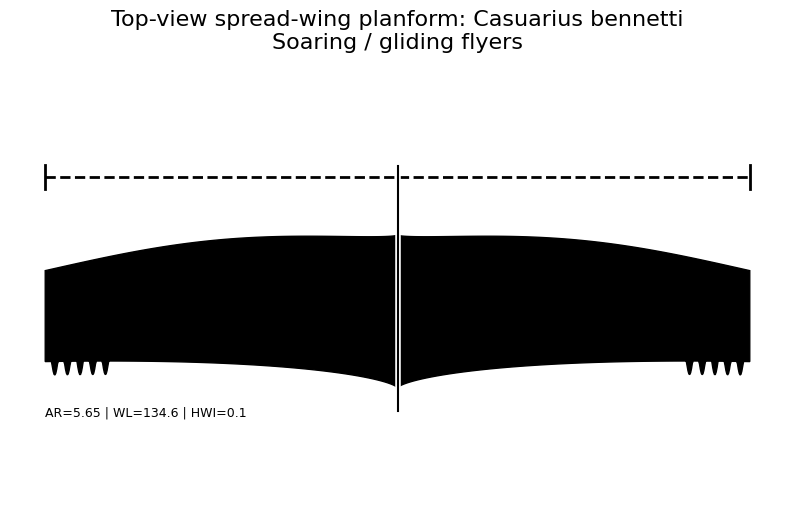

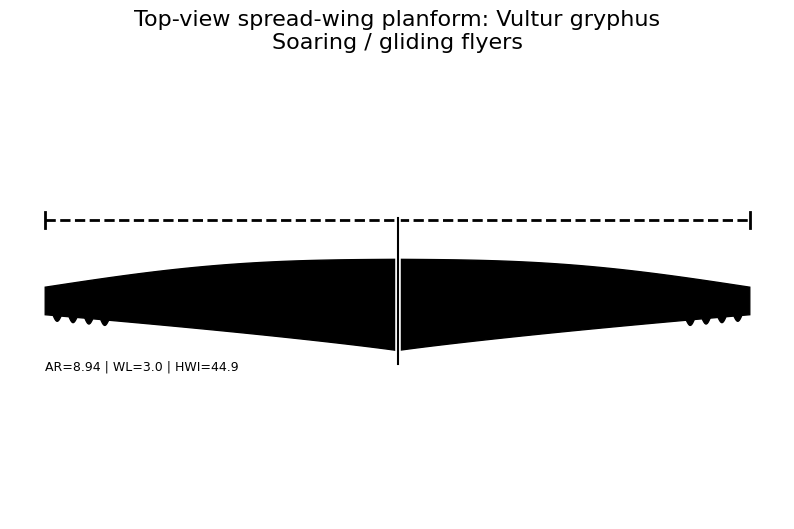

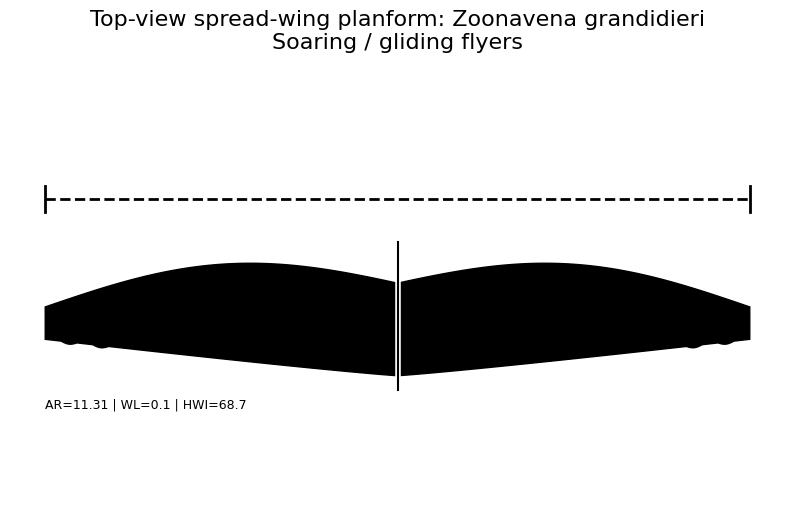

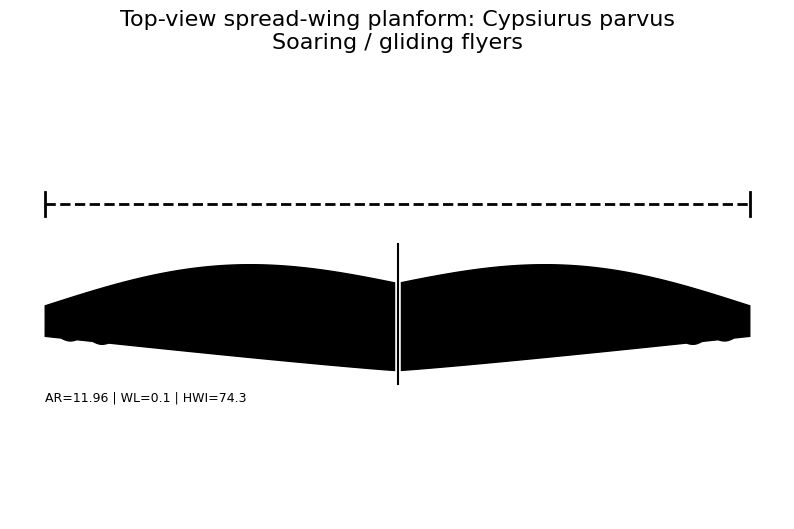

Saved top-view wing planform images in the generated_top_view_wings folder.


In [96]:
if "birds_features" in globals():
    os.makedirs("generated_top_view_wings", exist_ok=True)

    # Select more diverse examples instead of purely random examples.
    # This avoids accidentally selecting several birds with very similar features.
    examples = []

    # One example from each flight style, if available.
    for style_name, group in birds_features.groupby("flight_style"):
        examples.append(group.sample(1, random_state=RANDOM_STATE))

    # Add morphology extremes to make visual differences obvious.
    extreme_indices = set()
    for col in ["aspect_ratio_est", "wing_loading_N_m2", "morphology_based_speed_index", "wingspan_m"]:
        extreme_indices.add(birds_features[col].idxmin())
        extreme_indices.add(birds_features[col].idxmax())

    if extreme_indices:
        examples.append(birds_features.loc[list(extreme_indices)])

    sample_birds = (
        pd.concat(examples)
        .drop_duplicates(subset=["species"])
        .head(8)
    )

    print("Birds selected for top-view wing examples:")
    display(sample_birds[[
        "species",
        "flight_style",
        "aspect_ratio_est",
        "wing_loading_N_m2",
        "morphology_based_speed_index",
        "hwi_filled"
    ]])

    for idx, row in sample_birds.iterrows():
        safe_name = str(row["species"]).replace("/", "_").replace(" ", "_")[:60]
        save_path = os.path.join("generated_top_view_wings", f"{safe_name}_top_view_wing.png")
        generate_top_view_wing_planform(row, save_path=save_path)

    print("Saved top-view wing planform images in the generated_top_view_wings folder.")


## 15. Generate wing images for several birds

This cell saves example wing model images to a folder called `generated_wings`.


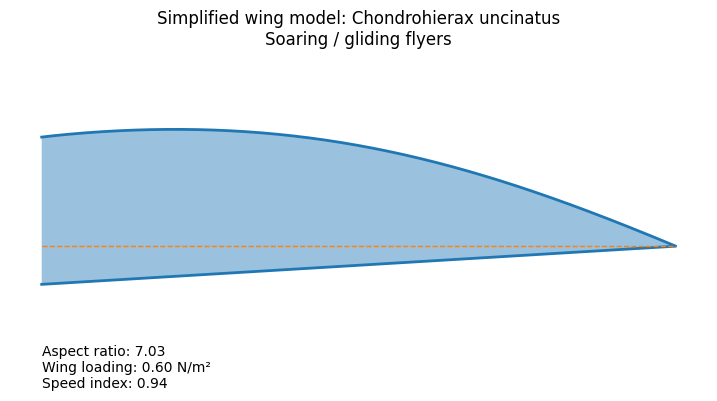

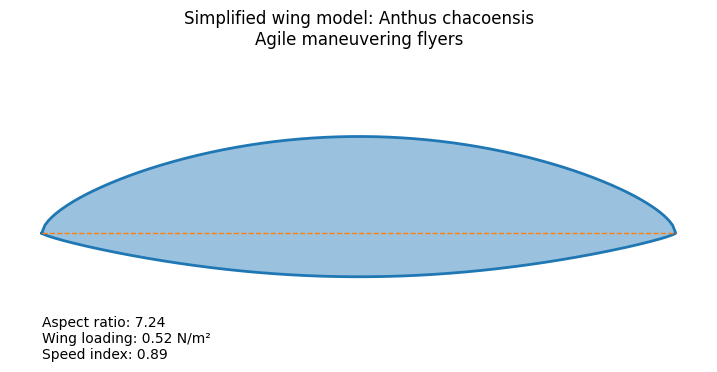

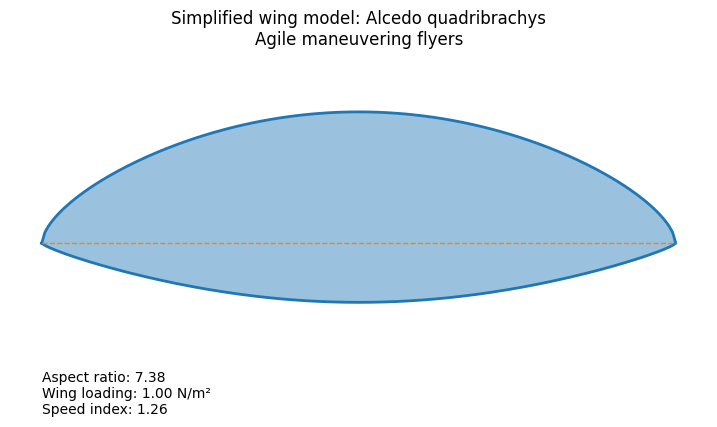

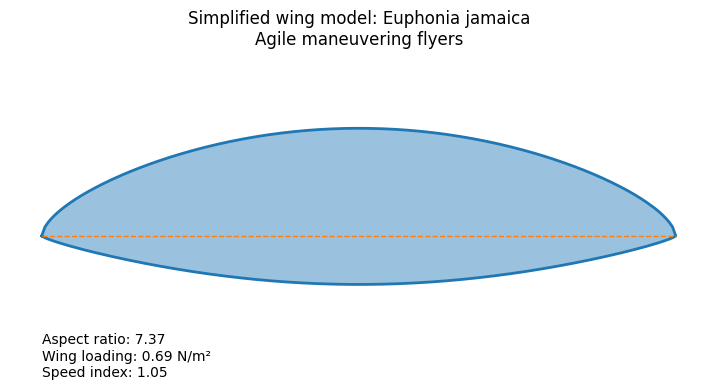

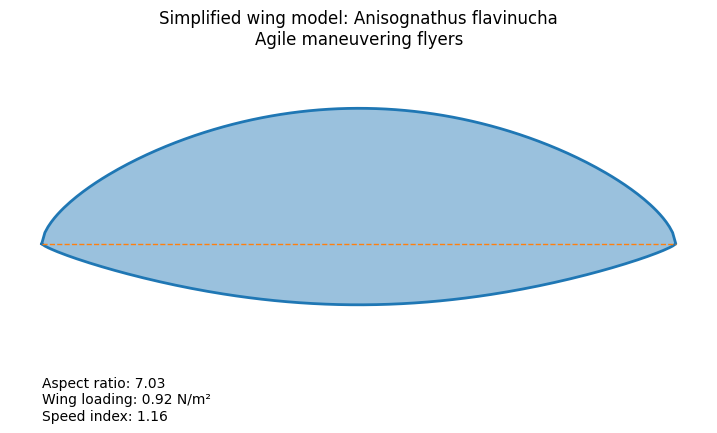

Saved generated wing images in the generated_wings folder.


In [97]:
if "birds_features" in globals():
    os.makedirs("generated_wings", exist_ok=True)

    sample_birds = birds_features.sample(
        min(5, len(birds_features)),
        random_state=RANDOM_STATE
    )

    for idx, row in sample_birds.iterrows():
        safe_name = str(row["species"]).replace("/", "_").replace(" ", "_")[:60]
        save_path = os.path.join("generated_wings", f"{safe_name}_wing_model.png")
        generate_wing_model(row, save_path=save_path)

    print("Saved generated wing images in the generated_wings folder.")


## 16. Try your own bird input

This function lets a user manually enter bird morphology values and receive a predicted flight group.

This is useful for demonstrating the program as an AI application.


Custom bird: Example Falcon-like Bird
Predicted cluster: 3
Predicted flight style: Soaring / gliding flyers

Computed features:


,mass_kg,wing_length_m,wingspan_m,aspect_ratio_est,wing_loading_N_m2,morphology_based_speed_index
0,0.9,0.32,0.95,13.494318,132.01256,16.315334


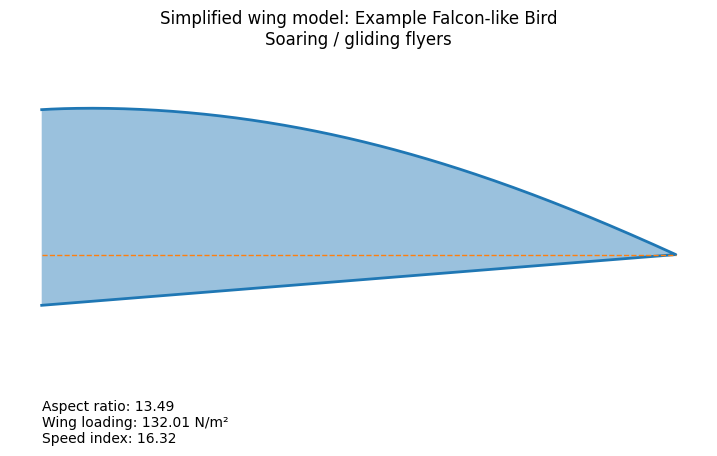

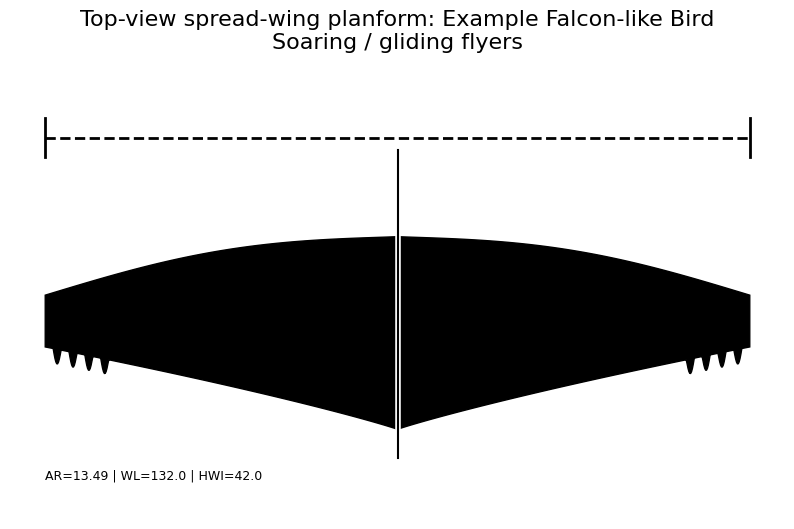

In [98]:
def predict_custom_bird(
    species_name,
    mass_kg,
    wing_length_m,
    wingspan_m=None,
    hwi=None
):
    if wingspan_m is None:
        wingspan_m = wing_length_m * 2.15

    wing_area_m2 = wingspan_m * wing_length_m * 0.22
    aspect_ratio_est = (wingspan_m ** 2) / wing_area_m2
    wing_loading_N_m2 = (mass_kg * 9.81) / wing_area_m2

    if hwi is None:
        hwi_value = birds_features["hwi"].median() if birds_features["hwi"].notna().any() else 25
    else:
        hwi_value = hwi

    morphology_based_speed_index = np.sqrt(wing_loading_N_m2) * (1 + hwi_value / 100)

    custom = pd.DataFrame([{
        "species": species_name,
        "mass_kg": mass_kg,
        "wing_length_m": wing_length_m,
        "wingspan_m": wingspan_m,
        "aspect_ratio_est": aspect_ratio_est,
        "wing_loading_N_m2": wing_loading_N_m2,
        "morphology_based_speed_index": morphology_based_speed_index,
        "hwi": hwi_value,
        "hwi_filled": hwi_value,
        "wing_area_m2": wing_area_m2
    }])

    # Match model features exactly.
    for col in feature_cols:
        if col not in custom.columns:
            custom[col] = 0

    predicted_cluster = int(classifier.predict(custom[feature_cols])[0])
    predicted_style = cluster_to_style[predicted_cluster]
    custom["cluster"] = predicted_cluster
    custom["flight_style"] = predicted_style

    print("Custom bird:", species_name)
    print("Predicted cluster:", predicted_cluster)
    print("Predicted flight style:", predicted_style)
    print()
    print("Computed features:")
    display(custom[["mass_kg", "wing_length_m", "wingspan_m", "aspect_ratio_est", "wing_loading_N_m2", "morphology_based_speed_index"]])

    generate_wing_model(custom.iloc[0])
    generate_top_view_wing_planform(custom.iloc[0])

    return custom


# Example custom bird:
# Change these values and rerun.
if "classifier" in globals():
    custom_bird = predict_custom_bird(
        species_name="Example Falcon-like Bird",
        mass_kg=0.9,
        wing_length_m=0.32,
        wingspan_m=0.95,
        hwi=42
    )


## 17. Save final results

This cell saves the processed dataset with AI-generated labels.


In [99]:
if "birds_features" in globals():
    output_file = "bird_flight_ai_results.csv"
    birds_features.to_csv(output_file, index=False)
    print(f"Saved results to {output_file}")


Saved results to bird_flight_ai_results.csv


## 18. Project conclusion

This project demonstrates an AI program that analyzes bird morphology and creates an interpretable flight-style classification system.

The system:

1. Ingests a real bird morphology dataset.
2. Cleans and preprocesses raw data.
3. Engineers biologically meaningful flight features.
4. Uses unsupervised AI to discover groups of birds.
5. Uses supervised AI to classify birds into those groups.
6. Explains the classification using flight-related features.
7. Generates simplified wing model images from the AI output.
8. Generates a top-view wing planform diagram with a vertical symmetry axis.

## Why this proves AI learning

The notebook includes multiple concepts from an AI course:

- machine learning pipeline design
- clustering
- classification
- feature engineering
- evaluation metrics
- explainability
- generated visual output

The program is not only analyzing data; it also turns the AI result into an interpretable and visual product.


# Multimodal Extension: Image-Based Bird Family Classification

This section upgrades the project from a tabular morphology AI system into a **multimodal AI system**.

The new pipeline is:

```text
Bird image
   ↓
Computer vision model predicts bird family
   ↓
Predicted family is linked to morphology data
   ↓
Flight-style classifier predicts likely flight group
   ↓
Wing planform generator creates a visual model
```

For a class project, this is stronger than only predicting exact species because **family-level prediction** is more realistic and easier to train with a smaller dataset.

## Folder structure expected

Create a folder called `bird_family_images` in the same directory as the notebook.

Inside it, create one folder per bird family or category:

```text
bird_family_images/
    Accipitridae/
        image1.jpg
        image2.jpg
    Anatidae/
        image1.jpg
        image2.jpg
    Columbidae/
        image1.jpg
        image2.jpg
    Strigidae/
        image1.jpg
        image2.jpg
```

You can start with 5–10 bird families/classes.


In [100]:
# Multimodal image-classification imports

import os
from pathlib import Path

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, random_split

    import torchvision
    from torchvision import datasets, transforms, models

    from PIL import Image

    TORCH_AVAILABLE = True
    print("PyTorch and torchvision are available.")
    print("Torch version:", torch.__version__)
except Exception as e:
    TORCH_AVAILABLE = False
    print("PyTorch / torchvision is not available yet.")
    print("Install it with:")
    print("pip install torch torchvision pillow")
    print("Error:", e)


PyTorch and torchvision are available.
Torch version: 2.11.0+cpu


## 19. Image classifier configuration

This section trains a bird-family classifier from image folders.

For the first version, use a small image dataset.  
Even 50–100 images per family can be enough for a class demo if the categories are visually different.

The model uses **transfer learning** with MobileNetV2:

- MobileNetV2 is already trained on many general image patterns.
- We replace the final classification layer.
- Then we fine-tune it on your bird-family images.


In [101]:
IMAGE_DATA_DIR = "bird_family_images"

BATCH_SIZE = 16
IMAGE_SIZE = 224
NUM_EPOCHS = 5
LEARNING_RATE = 0.001

device = "cuda" if TORCH_AVAILABLE and torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cpu


## 20. Load bird-family image dataset

The folder names become the class labels.

For example:

```text
bird_family_images/Accipitridae
bird_family_images/Anatidae
bird_family_images/Columbidae
```

The model will learn to classify images into these family labels.


In [102]:
if TORCH_AVAILABLE:
    data_path = Path(IMAGE_DATA_DIR)

    if not data_path.exists():
        print(f"Image folder not found: {IMAGE_DATA_DIR}")
        print("Create this folder and add one subfolder per bird family.")
    else:
        image_transforms = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        full_image_dataset = datasets.ImageFolder(
            root=IMAGE_DATA_DIR,
            transform=image_transforms
        )

        class_names = full_image_dataset.classes
        num_classes = len(class_names)

        print("Classes found:")
        for i, name in enumerate(class_names):
            print(i, name)

        print("Total images:", len(full_image_dataset))

        if len(full_image_dataset) < 10 or num_classes < 2:
            print("Add more images/classes before training.")
        else:
            train_size = int(0.8 * len(full_image_dataset))
            val_size = len(full_image_dataset) - train_size

            train_dataset, val_dataset = random_split(
                full_image_dataset,
                [train_size, val_size],
                generator=torch.Generator().manual_seed(RANDOM_STATE)
            )

            train_loader = DataLoader(
                train_dataset,
                batch_size=BATCH_SIZE,
                shuffle=True
            )

            val_loader = DataLoader(
                val_dataset,
                batch_size=BATCH_SIZE,
                shuffle=False
            )

            print("Training images:", len(train_dataset))
            print("Validation images:", len(val_dataset))


Classes found:
0 Accipitridae
1 Anatidae
2 Columbidae
3 Picidae
4 Strigidae
Total images: 72
Training images: 57
Validation images: 15


## 21. Show sample training images

This confirms that the folder loading worked correctly.


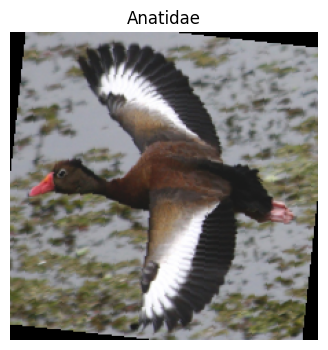

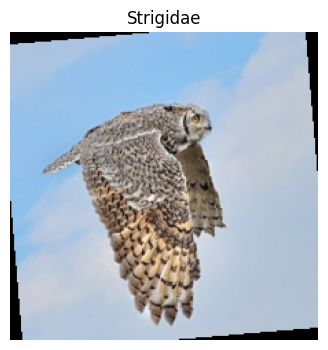

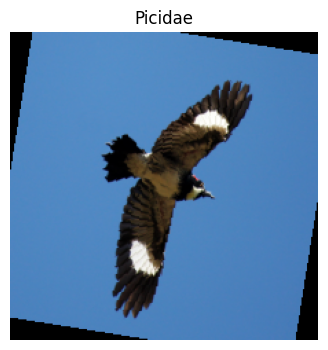

In [103]:
def imshow_tensor(img_tensor, title=None):
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()


if TORCH_AVAILABLE and "train_loader" in globals():
    images, labels = next(iter(train_loader))

    for i in range(min(3, len(images))):
        imshow_tensor(images[i], title=class_names[labels[i]])


## 22. Build transfer-learning image classifier

This uses **MobileNetV2** as a pretrained computer vision backbone.

The final layer is replaced so it predicts your bird-family labels.

If pretrained weights cannot be downloaded, the code falls back to an untrained MobileNetV2.  
The pretrained version is better, but the fallback still lets the notebook run.


In [104]:
if TORCH_AVAILABLE and "num_classes" in globals() and num_classes >= 2:
    try:
        weights = models.MobileNet_V2_Weights.DEFAULT
        image_model = models.mobilenet_v2(weights=weights)
        print("Loaded MobileNetV2 with pretrained weights.")
    except Exception as e:
        image_model = models.mobilenet_v2(weights=None)
        print("Could not load pretrained weights. Using untrained MobileNetV2.")
        print("Reason:", e)

    in_features = image_model.classifier[1].in_features
    image_model.classifier[1] = nn.Linear(in_features, num_classes)

    image_model = image_model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(image_model.parameters(), lr=LEARNING_RATE)

    print(image_model.classifier)


Loaded MobileNetV2 with pretrained weights.
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)


## 23. Train the image classifier

This trains the model to classify bird families from images.

For a real project, you can increase `NUM_EPOCHS` to 10–20 if the dataset is large enough.


In [105]:
def train_image_classifier(model, train_loader, val_loader, num_epochs):
    history = {
        "train_loss": [],
        "val_accuracy": []
    }

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total if total > 0 else 0

        history["train_loss"].append(epoch_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch + 1}/{num_epochs} | Loss: {epoch_loss:.4f} | Val Accuracy: {val_acc:.3f}")

    return history


if TORCH_AVAILABLE and "image_model" in globals() and "train_loader" in globals():
    image_history = train_image_classifier(
        image_model,
        train_loader,
        val_loader,
        NUM_EPOCHS
    )


Epoch 1/5 | Loss: 1.5327 | Val Accuracy: 0.333
Epoch 2/5 | Loss: 0.7739 | Val Accuracy: 0.733
Epoch 3/5 | Loss: 0.3576 | Val Accuracy: 0.867
Epoch 4/5 | Loss: 0.1360 | Val Accuracy: 0.733
Epoch 5/5 | Loss: 0.0392 | Val Accuracy: 0.800


## 24. Plot image-classifier training results

This plot shows whether the image classifier improved during training.


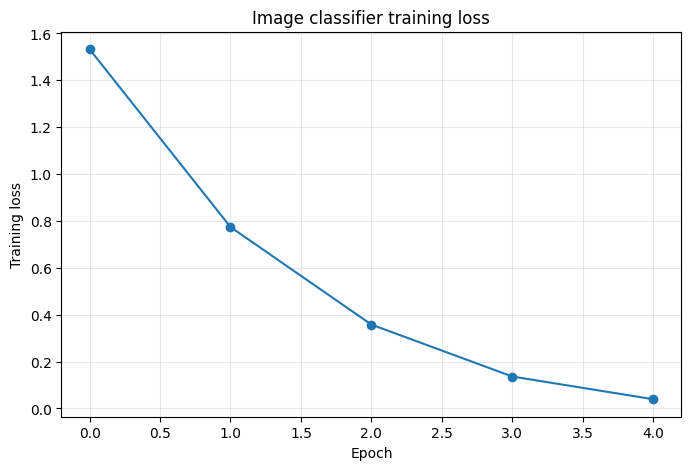

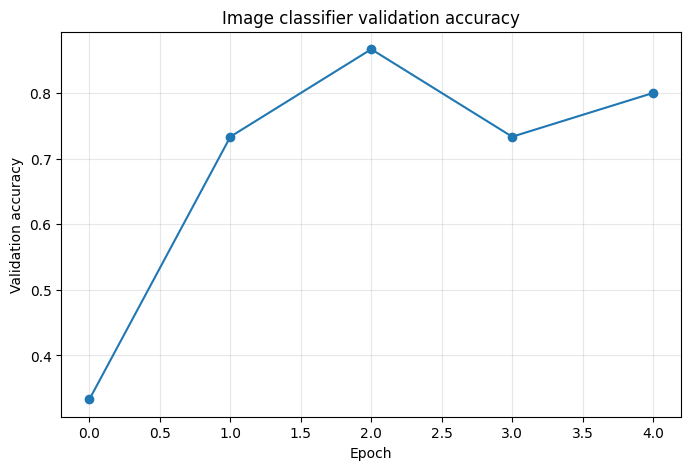

In [106]:
if "image_history" in globals():
    plt.figure(figsize=(8, 5))
    plt.plot(image_history["train_loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("Image classifier training loss")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(image_history["val_accuracy"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Validation accuracy")
    plt.title("Image classifier validation accuracy")
    plt.grid(True, alpha=0.3)
    plt.show()


## 25. Predict bird family from a new image

There are now **two ways** to provide a bird image:

### Option 1 — file path
Put a test bird image in the notebook folder and set:

```python
TEST_IMAGE_PATH = "test_bird.jpg"
```

### Option 2 — upload widget
Use the Jupyter upload workflow in the next section to upload an image directly from your computer.

Both methods use the same image-classification model.


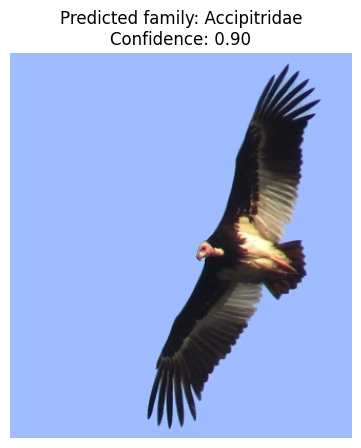

Predicted family: Accipitridae
Confidence: 0.9001926183700562


In [119]:
def predict_bird_family_from_image(image_path, model=None):
    if model is None:
        if "image_model" not in globals():
            raise ValueError("Image model has not been trained yet.")
        model = image_model

    model.eval()

    predict_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    img = Image.open(image_path).convert("RGB")
    img_tensor = predict_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        confidence, pred_idx = torch.max(probabilities, 0)

    predicted_family = class_names[pred_idx.item()]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Predicted family: {predicted_family}\nConfidence: {confidence.item():.2f}")
    plt.axis("off")
    plt.show()

    return predicted_family, confidence.item(), probabilities.cpu().numpy()


TEST_IMAGE_PATH = "sample3.jpg"

if TORCH_AVAILABLE and "image_model" in globals():
    if os.path.exists(TEST_IMAGE_PATH):
        predicted_family, confidence, family_probabilities = predict_bird_family_from_image(TEST_IMAGE_PATH)
        print("Predicted family:", predicted_family)
        print("Confidence:", confidence)
    else:
        print(f"No test image found at {TEST_IMAGE_PATH}.")
        print("Add a test image or change TEST_IMAGE_PATH.")


## 25A. Upload a bird image inside Jupyter (Option 2)

This section lets you **upload a bird image directly inside the notebook** using a file upload widget.

This is more convenient than manually copying a file into the notebook folder.

### Supported file types
- `.jpg`
- `.jpeg`
- `.png`

### Workflow
1. Run the widget cell.
2. Choose an image from your computer.
3. Run the save cell.
4. Run the prediction cell.
5. Run the morphology-linking cell to generate the wing outputs.


In [108]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
    print("ipywidgets is available.")
except Exception as e:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not available yet.")
    print("Install it with:")
    print("pip install ipywidgets")
    print("Error:", e)


ipywidgets is available.


In [109]:
if WIDGETS_AVAILABLE:
    upload_widget = widgets.FileUpload(
        accept=".jpg,.jpeg,.png",
        multiple=False,
        description="Upload bird image"
    )
    display(upload_widget)


FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload bird image')

In [120]:
def save_uploaded_bird_image(upload_widget, output_path="uploaded_bird.jpg"):
    """Save the uploaded bird image from the Jupyter FileUpload widget."""
    if upload_widget is None:
        print("Upload widget is not defined.")
        return None

    # Different ipywidgets versions may expose the value differently.
    if len(upload_widget.value) == 0:
        print("No image uploaded yet.")
        return None

    value = upload_widget.value

    # Case 1: dict-like structure
    if isinstance(value, dict):
        uploaded_file = list(value.values())[0]
        content = uploaded_file["content"]
        filename = uploaded_file.get("metadata", {}).get("name", output_path)
    else:
        # Case 2: tuple/list-like structure
        uploaded_file = value[0]
        content = uploaded_file["content"]
        filename = uploaded_file.get("name", output_path)

    # Keep original extension if possible
    suffix = Path(filename).suffix if Path(filename).suffix else ".jpg"
    output_path = str(Path(output_path).with_suffix(suffix))

    with open(output_path, "wb") as f:
        f.write(content)

    print(f"Saved uploaded image as: {output_path}")
    return output_path


uploaded_image_path = None

if WIDGETS_AVAILABLE and "upload_widget" in globals():
    uploaded_image_path = save_uploaded_bird_image(upload_widget)


Saved uploaded image as: uploaded_bird.jpg


## 25B. Predict the bird family from the uploaded image

After saving the uploaded image, run this cell to classify it with the trained image model.


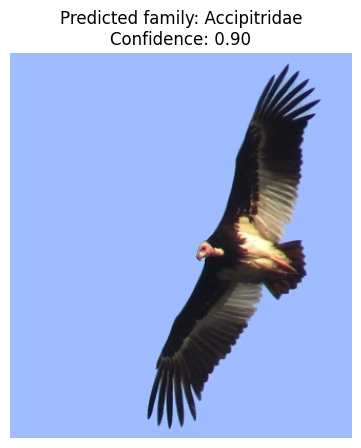

Predicted family: Accipitridae
Confidence: 0.9001926183700562


In [121]:
if TORCH_AVAILABLE and "image_model" in globals():
    if "uploaded_image_path" in globals() and uploaded_image_path is not None and os.path.exists(uploaded_image_path):
        predicted_family, confidence, family_probabilities = predict_bird_family_from_image(uploaded_image_path)

        print("Predicted family:", predicted_family)
        print("Confidence:", confidence)
    else:
        print("No uploaded image is available yet.")
        print("Please upload an image and run the save cell first.")


## 25C. Generate morphology-based outputs from the uploaded image prediction

Once the bird family has been predicted, this cell connects the prediction back to the morphology dataset and generates:

1. the simplified wing model
2. the top-view wing planform


Image-predicted family: Anatidae
Number of morphology rows used: 166
Predicted flight style from average morphology: Soaring / gliding flyers

Average morphology values used:


mass_kg                         1.433783
wing_length_m                   2.609892
wingspan_m                      5.991222
aspect_ratio_est                 9.00703
wing_loading_N_m2                3.03738
morphology_based_speed_index    2.482225
hwi_filled                      45.51506
Name: 251, dtype: object

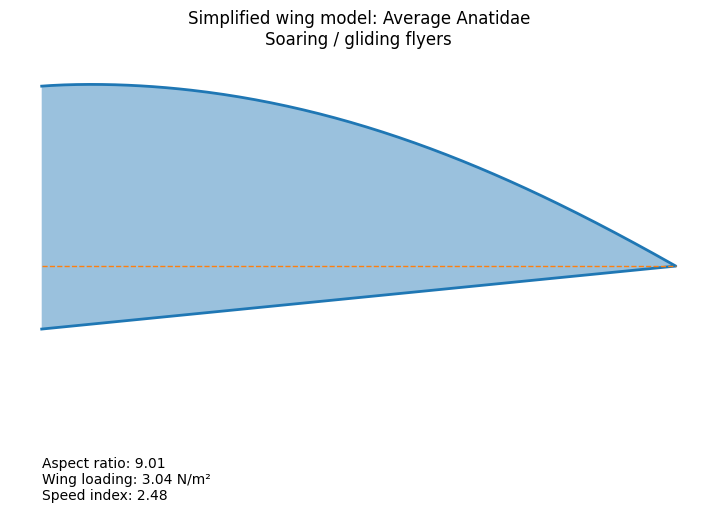

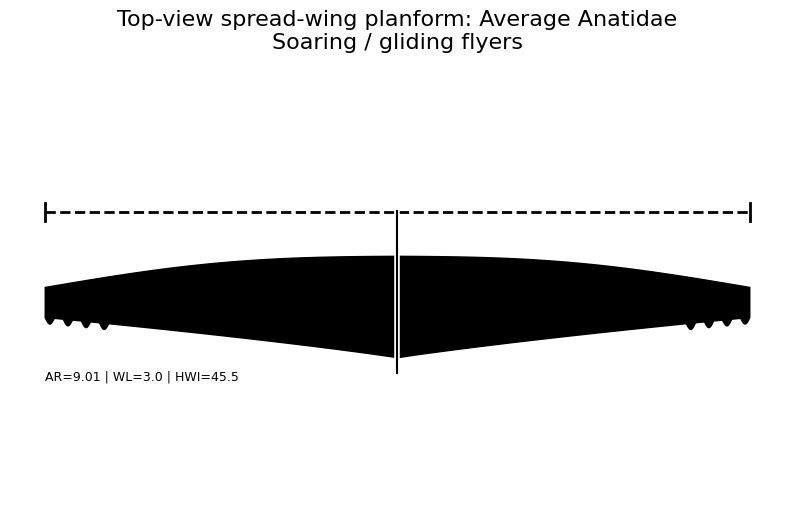

In [112]:
if "predicted_family" in globals():
    representative_from_uploaded_image = generate_wing_from_predicted_family(predicted_family)
else:
    print("No predicted family found yet.")
    print("Run the uploaded-image prediction cell first.")


## 25D. Optional: show all class probabilities

This is useful if you want to see the model's uncertainty.


,family,probability
1,Anatidae,0.936564
0,Accipitridae,0.033853
2,Columbidae,0.012409
3,Picidae,0.009876
4,Strigidae,0.007298


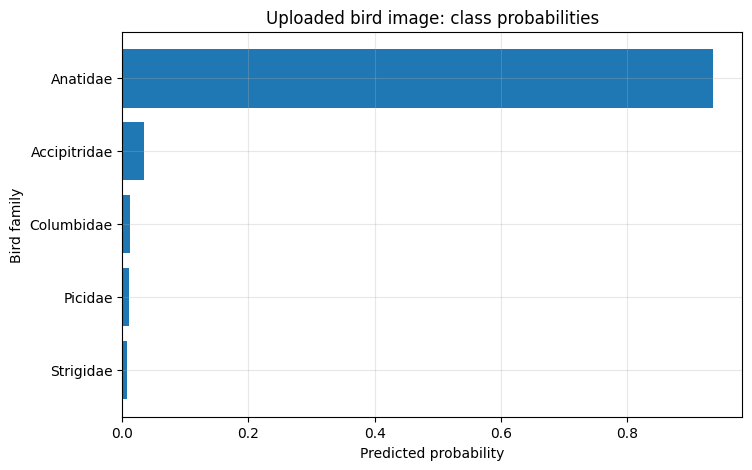

In [113]:
if "family_probabilities" in globals() and "class_names" in globals():
    prob_df = pd.DataFrame({
        "family": class_names,
        "probability": family_probabilities
    }).sort_values("probability", ascending=False)

    display(prob_df)

    plt.figure(figsize=(8, 5))
    plt.barh(prob_df["family"], prob_df["probability"])
    plt.xlabel("Predicted probability")
    plt.ylabel("Bird family")
    plt.title("Uploaded bird image: class probabilities")
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3)
    plt.show()


## 26. Link image prediction to morphology and wing generation

Now we connect the image model back to the morphology AI system.

If the image model predicts a family that exists in the morphology dataset, we create an average morphology profile for that family and use it to:

1. predict flight style
2. generate a wing model
3. generate a top-view wing planform

This depends on whether the dataset has a family column.


In [114]:
if "birds_raw" in globals():
    family_col = find_column(birds_raw, [
        ["family"],
        ["family1"],
        ["taxon", "family"]
    ])

    print("Detected family column:", family_col)

    # Optional manual override:
    # family_col = "Family1"


Detected family column: Family1


In [115]:
def add_family_to_features():
    if family_col is None:
        print("No family column found. Cannot link image family prediction to morphology.")
        return None

    if species_col is None:
        print("No species column found. Cannot safely merge family labels.")
        return None

    family_lookup = birds_raw[[species_col, family_col]].copy()
    family_lookup = family_lookup.rename(columns={
        species_col: "species",
        family_col: "family"
    })
    family_lookup = family_lookup.drop_duplicates(subset=["species"])

    merged = birds_features.merge(family_lookup, on="species", how="left")
    return merged


if "birds_features" in globals() and "birds_raw" in globals():
    birds_features_with_family = add_family_to_features()

    if birds_features_with_family is not None:
        print("Rows with family labels:", birds_features_with_family["family"].notna().sum())
        display(birds_features_with_family[["species", "family", "flight_style"]].head())


Rows with family labels: 11009


,species,family,flight_style
0,Accipiter albogularis,Accipitridae,Soaring / gliding flyers
1,Accipiter badius,Accipitridae,Soaring / gliding flyers
2,Accipiter bicolor,Accipitridae,Agile maneuvering flyers
3,Accipiter brachyurus,Accipitridae,Soaring / gliding flyers
4,Accipiter brevipes,Accipitridae,Soaring / gliding flyers


Image-predicted family: Anatidae
Number of morphology rows used: 166
Predicted flight style from average morphology: Soaring / gliding flyers

Average morphology values used:


mass_kg                         1.433783
wing_length_m                   2.609892
wingspan_m                      5.991222
aspect_ratio_est                 9.00703
wing_loading_N_m2                3.03738
morphology_based_speed_index    2.482225
hwi_filled                      45.51506
Name: 251, dtype: object

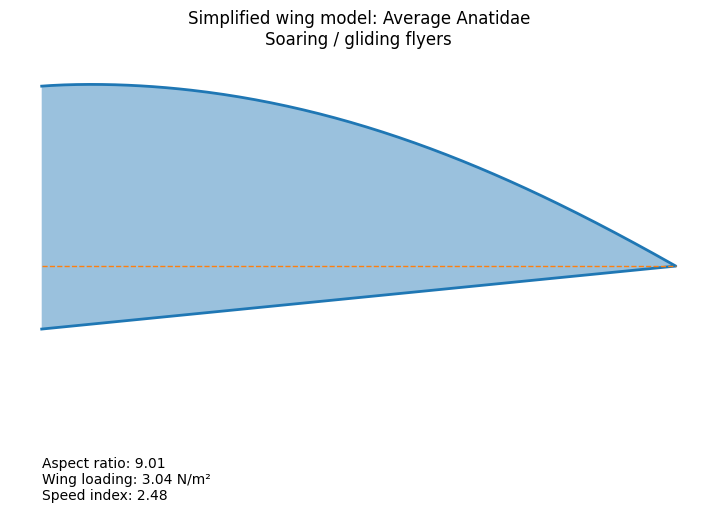

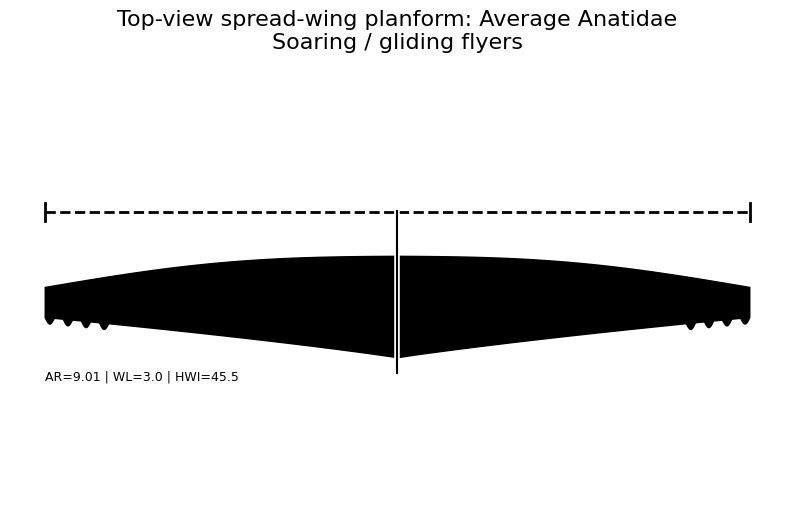

In [116]:
def generate_wing_from_predicted_family(predicted_family):
    if "birds_features_with_family" not in globals() or birds_features_with_family is None:
        print("Family-linked morphology table is not available.")
        return None

    family_rows = birds_features_with_family[
        birds_features_with_family["family"].astype(str).str.lower() == predicted_family.lower()
    ]

    if len(family_rows) == 0:
        print(f"No morphology rows found for predicted family: {predicted_family}")
        print("Available families include:")
        print(sorted(birds_features_with_family["family"].dropna().unique())[:20])
        return None

    avg = family_rows[feature_cols + ["wing_area_m2"]].mean(numeric_only=True)
    representative = family_rows.iloc[0].copy()

    for col in avg.index:
        representative[col] = avg[col]

    representative["species"] = f"Average {predicted_family}"
    representative_X = representative[feature_cols].to_frame().T

    predicted_cluster = int(classifier.predict(representative_X)[0])
    representative["cluster"] = predicted_cluster
    representative["flight_style"] = cluster_to_style[predicted_cluster]

    print("Image-predicted family:", predicted_family)
    print("Number of morphology rows used:", len(family_rows))
    print("Predicted flight style from average morphology:", representative["flight_style"])

    print()
    print("Average morphology values used:")
    display(representative[feature_cols])

    generate_wing_model(representative)
    generate_top_view_wing_planform(representative)

    return representative


if "predicted_family" in globals():
    representative_from_image = generate_wing_from_predicted_family(predicted_family)


## 27. Optional explainability: Grad-CAM future improvement

A strong future improvement would be adding **Grad-CAM**.

Grad-CAM highlights the image regions that influenced the CNN prediction.  
For bird classification, this could show whether the model focused on:

- head shape
- beak
- wing shape
- tail shape
- body pattern or color

This would make the project more explainable because the system would not only say:

```text
Predicted family: Accipitridae
```

It could also show **where in the image the model looked** when making that decision.


## 28. Multimodal project conclusion

With this extension, the project becomes a multimodal AI system.

The final system can use:

1. **tabular morphology data** to classify flight style
2. **computer vision** to classify bird family from an image
3. **morphology lookup** to connect image prediction to flight features
4. **AI explanation** to describe why a bird belongs to a flight group
5. **generated wing visualization** to create an interpretable output

This is a stronger AI project because it combines multiple AI techniques instead of using only one model.


Additional usability improvement:
- the notebook can now accept a bird image uploaded directly inside Jupyter through an interactive upload widget
